**WEEK - 4**

**Step 1.Mount Google Drive**

In [26]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**HYPERPARAMETERS**

In [ ]:
# ------------------- IMPORTS -------------------
import os, random
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# ------------------- HYPERPARAMETERS -------------------
HYPERPARAMS = {
    "img_height": 256,
    "img_width": 256,
    "batch_size": 8,
    "epochs": 20,
    "limit": 400,
    "seed": 42,
    "learning_rate": 1e-4,
    "dropout_rate": 0.5
}

IMG_H, IMG_W = HYPERPARAMS["img_height"], HYPERPARAMS["img_width"]
BATCH_SIZE   = HYPERPARAMS["batch_size"]
EPOCHS       = HYPERPARAMS["epochs"]
LIMIT        = HYPERPARAMS["limit"]
SEED         = HYPERPARAMS["seed"]

# ------------------- PATHS -------------------
IMAGE_DIR = "/content/drive/MyDrive/VisionExtract/data/coco2017/original_images"
MASK_DIR  = "/content/drive/MyDrive/VisionExtract/data/coco2017/train_masks"

# ------------------- PAIRING IMAGES AND MASKS -------------------
def get_pairs(img_dir, mask_dir):
    img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    mask_files = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    mask_set = set(mask_files)
    pairs = []
    for img in img_files:
        stem = os.path.splitext(img)[0]
        expected_mask = stem + "_mask.png"
        if expected_mask in mask_set:
            pairs.append((os.path.join(img_dir, img), os.path.join(mask_dir, expected_mask)))
    return pairs

pairs = get_pairs(IMAGE_DIR, MASK_DIR)
if LIMIT:
    pairs = pairs[:LIMIT]

random.seed(SEED)
random.shuffle(pairs)

# ------------------- LOAD DATA -------------------
def load_pairs_to_numpy(pairs, img_h=IMG_H, img_w=IMG_W):
    X, Y = [], []
    for img_path, mask_path in pairs:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_w, img_h))
        img = preprocess_input(img.astype(np.float32))

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.uint8)
        mask = mask[..., np.newaxis]

        X.append(img)
        Y.append(mask.astype(np.float32))
    return np.stack(X, axis=0), np.stack(Y, axis=0)

X, y = load_pairs_to_numpy(pairs)

# ------------------- SPLIT TRAIN / VALIDATION -------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# ------------------- LOSS + METRICS -------------------
def dice_coef_tf(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss_tf(y_true, y_pred):
    return 1.0 - dice_coef_tf(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()
def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss_tf(y_true, y_pred)

class PixelAccuracy(tf.keras.metrics.Metric):
    def __init__(self, name='pixel_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_weight(name='correct', initializer='zeros')
        self.total = self.add_weight(name='total', initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
        y_true_f = tf.cast(y_true, tf.float32)
        correct = tf.reduce_sum(tf.cast(tf.equal(y_true_f, y_pred_bin), tf.float32))
        total = tf.cast(tf.size(y_true_f), tf.float32)
        self.correct.assign_add(correct)
        self.total.assign_add(total)
    def result(self):
        return self.correct / (self.total + 1e-8)
    def reset_states(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)

# ------------------- BUILD U-NET -------------------
def build_unet_resnet50(input_shape=(IMG_H, IMG_W, 3), backbone_trainable=False, dropout_rate=0.5):
    inputs = layers.Input(shape=input_shape)
    backbone = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)
    backbone.trainable = backbone_trainable

    c1 = backbone.get_layer("conv1_relu").output
    c2 = backbone.get_layer("conv2_block3_out").output
    c3 = backbone.get_layer("conv3_block4_out").output
    c4 = backbone.get_layer("conv4_block6_out").output
    c5 = backbone.get_layer("conv5_block3_out").output

    def decoder_block(x, skip, filters):
        x = layers.UpSampling2D(size=(2,2))(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        return x

    d4 = decoder_block(c5, c4, 512)
    d3 = decoder_block(d4, c3, 256)
    d2 = decoder_block(d3, c2, 128)
    d1 = decoder_block(d2, c1, 64)

    x = layers.UpSampling2D(size=(2,2))(d1)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

# ------------------- MODEL -------------------
model = build_unet_resnet50(
    input_shape=(IMG_H, IMG_W, 3),
    backbone_trainable=False,
    dropout_rate=HYPERPARAMS["dropout_rate"]
)
model.compile(
    optimizer=Adam(learning_rate=HYPERPARAMS["learning_rate"]),
    loss=bce_dice_loss,
    metrics=[PixelAccuracy(), MeanIoU(num_classes=2)]
)

# ------------------- CALLBACKS -------------------
checkpoint = ModelCheckpoint(
    "unet_resnet50_best.keras",  # new format
    save_best_only=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ------------------- TRAINING -------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    shuffle=True,
    callbacks=[checkpoint, earlystop, reduce_lr]
)


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - loss: 1.5947 - mean_io_u: 0.3751 - pixel_accuracy: 0.5184 
Epoch 1: val_loss improved from inf to 1.29193, saving model to unet_resnet50_best.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 430s 26s/step - loss: 1.5869 - mean_io_u: 0.3750 - pixel_accuracy: 0.5230 - val_loss: 1.2919 - val_mean_io_u: 0.3871 - val_pixel_accuracy: 0.7610 - learning_rate: 1.0000e-04
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - loss: 1.2193 - mean_io_u: 0.3808 - pixel_accuracy: 0.7134 
Epoch 2: val_loss improved from 1.29193 to 0.67666, saving model to unet_resnet50_best.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 433s 25s/step - loss: 1.2100 - mean_io_u: 0.3804 - pixel_accuracy: 0.7160 - val_loss: 0.6767 - val_mean_io_u: 0.3871 - val_pixel_accuracy: 0.8615 - learning_rate: 1.0000e-04
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - loss: 0.5820 - mean_io_u: 0.3659 - pixel_accuracy: 0.8904 
Epoch 3: val_loss improved from 0.67666 to 0.59249, saving model to unet_resnet50_b

In [3]:
# ------------------- IMPORTS -------------------
import os, random
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# ------------------- HYPERPARAMETERS -------------------
HYPERPARAMS = {
    "img_height": 256,
    "img_width": 256,
    "batch_size": 8,
    "epochs": 10,       # train all 10 epochs
    "limit": 400,
    "seed": 42,
    "learning_rate": 1e-4,
    "dropout_rate": 0.3
}

IMG_H, IMG_W = HYPERPARAMS["img_height"], HYPERPARAMS["img_width"]
BATCH_SIZE   = HYPERPARAMS["batch_size"]
EPOCHS       = HYPERPARAMS["epochs"]
LIMIT        = HYPERPARAMS["limit"]
SEED         = HYPERPARAMS["seed"]

# ------------------- PATHS -------------------
IMAGE_DIR = "/content/drive/MyDrive/VisionExtract/data/coco2017/original_images"
MASK_DIR  = "/content/drive/MyDrive/VisionExtract/data/coco2017/train_masks"

# ------------------- PAIRING IMAGES AND MASKS -------------------
def get_pairs(img_dir, mask_dir):
    img_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    mask_files = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    mask_set = set(mask_files)
    pairs = []
    for img in img_files:
        stem = os.path.splitext(img)[0]
        expected_mask = stem + "_mask.png"
        if expected_mask in mask_set:
            pairs.append((os.path.join(img_dir, img), os.path.join(mask_dir, expected_mask)))
    return pairs

pairs = get_pairs(IMAGE_DIR, MASK_DIR)
if LIMIT:
    pairs = pairs[:LIMIT]

random.seed(SEED)
random.shuffle(pairs)

# ------------------- LOAD DATA -------------------
def load_pairs_to_numpy(pairs, img_h=IMG_H, img_w=IMG_W):
    X, Y = [], []
    for img_path, mask_path in pairs:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_w, img_h))
        img = preprocess_input(img.astype(np.float32))

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_w, img_h), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.uint8)
        mask = mask[..., np.newaxis]

        X.append(img)
        Y.append(mask.astype(np.float32))
    return np.stack(X, axis=0), np.stack(Y, axis=0)

X, y = load_pairs_to_numpy(pairs)

# ------------------- SPLIT TRAIN / VALIDATION -------------------
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED)

# ------------------- DATA AUGMENTATION -------------------
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# ------------------- LOSS + METRICS -------------------
def dice_coef_tf(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss_tf(y_true, y_pred):
    return 1.0 - dice_coef_tf(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()
def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss_tf(y_true, y_pred)

class PixelAccuracy(tf.keras.metrics.Metric):
    def __init__(self, name='pixel_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_weight(name='correct', initializer='zeros')
        self.total = self.add_weight(name='total', initializer='zeros')
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
        y_true_f = tf.cast(y_true, tf.float32)
        correct = tf.reduce_sum(tf.cast(tf.equal(y_true_f, y_pred_bin), tf.float32))
        total = tf.cast(tf.size(y_true_f), tf.float32)
        self.correct.assign_add(correct)
        self.total.assign_add(total)
    def result(self):
        return self.correct / (self.total + 1e-8)
    def reset_states(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)

# ------------------- BUILD U-NET -------------------
def build_unet_resnet50(input_shape=(IMG_H, IMG_W, 3), backbone_trainable=False, dropout_rate=0.3):
    inputs = layers.Input(shape=input_shape)
    backbone = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)
    backbone.trainable = backbone_trainable

    c1 = backbone.get_layer("conv1_relu").output
    c2 = backbone.get_layer("conv2_block3_out").output
    c3 = backbone.get_layer("conv3_block4_out").output
    c4 = backbone.get_layer("conv4_block6_out").output
    c5 = backbone.get_layer("conv5_block3_out").output

    def decoder_block(x, skip, filters):
        x = layers.UpSampling2D(size=(2,2))(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.Dropout(dropout_rate)(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        return x

    d4 = decoder_block(c5, c4, 512)
    d3 = decoder_block(d4, c3, 256)
    d2 = decoder_block(d3, c2, 128)
    d1 = decoder_block(d2, c1, 64)

    x = layers.UpSampling2D(size=(2,2))(d1)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

# ------------------- MODEL -------------------
model = build_unet_resnet50(
    input_shape=(IMG_H, IMG_W, 3),
    backbone_trainable=False,
    dropout_rate=HYPERPARAMS["dropout_rate"]
)

model.compile(
    optimizer=Adam(learning_rate=HYPERPARAMS["learning_rate"]),
    loss=bce_dice_loss,
    metrics=[PixelAccuracy(), MeanIoU(num_classes=2)]
)

# ------------------- CALLBACKS -------------------
checkpoint = ModelCheckpoint(
    "unet_resnet50_best.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ------------------- TRAINING -------------------
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    epochs=EPOCHS,   # all 10 epochs
    callbacks=[checkpoint, reduce_lr]
)




/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - loss: 1.4895 - mean_io_u_1: 0.3874 - pixel_accuracy: 0.5558 
Epoch 1: val_loss improved from inf to 1.26599, saving model to unet_resnet50_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 392s 25s/step - loss: 1.4837 - mean_io_u_1: 0.3867 - pixel_accuracy: 0.5606 - val_loss: 1.2660 - val_mean_io_u_1: 0.3871 - val_pixel_accuracy: 0.7504 - learning_rate: 1.0000e-04
Epoch 2/10
 1/15 ━━━━━━━━━━━━━━━━━━━━ 7:07 31s/step - loss: 1.2634 - mean_io_u_1: 0.3237 - pixel_accuracy: 0.6039

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 1.26599 to 1.26529, saving model to unet_resnet50_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - loss: 1.2634 - mean_io_u_1: 0.3237 - pixel_accuracy: 0.6039 - val_loss: 1.2653 - val_mean_io_u_1: 0.3871 - val_pixel_accuracy: 0.7385 - learning_rate: 1.0000e-04
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - loss: 1.2886 - mean_io_u_1: 0.3783 - pixel_accuracy: 0.6787 
Epoch 3: val_loss improved from 1.26529 to 0.94493, saving model to unet_resnet50_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 370s 25s/step - loss: 1.2841 - mean_io_u_1: 0.3778 - pixel_accuracy: 0.6806 - val_loss: 0.9449 - val_mean_io_u_1: 0.3871 - val_pixel_accuracy: 0.7893 - learning_rate: 1.0000e-04
Epoch 4/10
 1/15 ━━━━━━━━━━━━━━━━━━━━ 5:35 24s/step - loss: 0.8819 - mean_io_u_1: 0.4127 - pixel_accuracy: 0.8511
Epoch 4: val_loss improved from 0.94493 to 0.86019, saving model to unet_resnet50_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - loss: 0.8819 - mean_io_u_1: 0.4127 - pixel_a

In [4]:
import os
print(os.getcwd())  # shows the current folder
print(os.path.exists("unet_resnet50_best.keras"))  # True if file exists


/content
True


In [5]:
import shutil

src = "/content/unet_resnet50_best.keras"
dst = "/content/drive/MyDrive/VisionExtract/unet_resnet50_best.keras"

shutil.move(src, dst)
print("Model moved to:", dst)


Model moved to: /content/drive/MyDrive/VisionExtract/unet_resnet50_best.keras


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


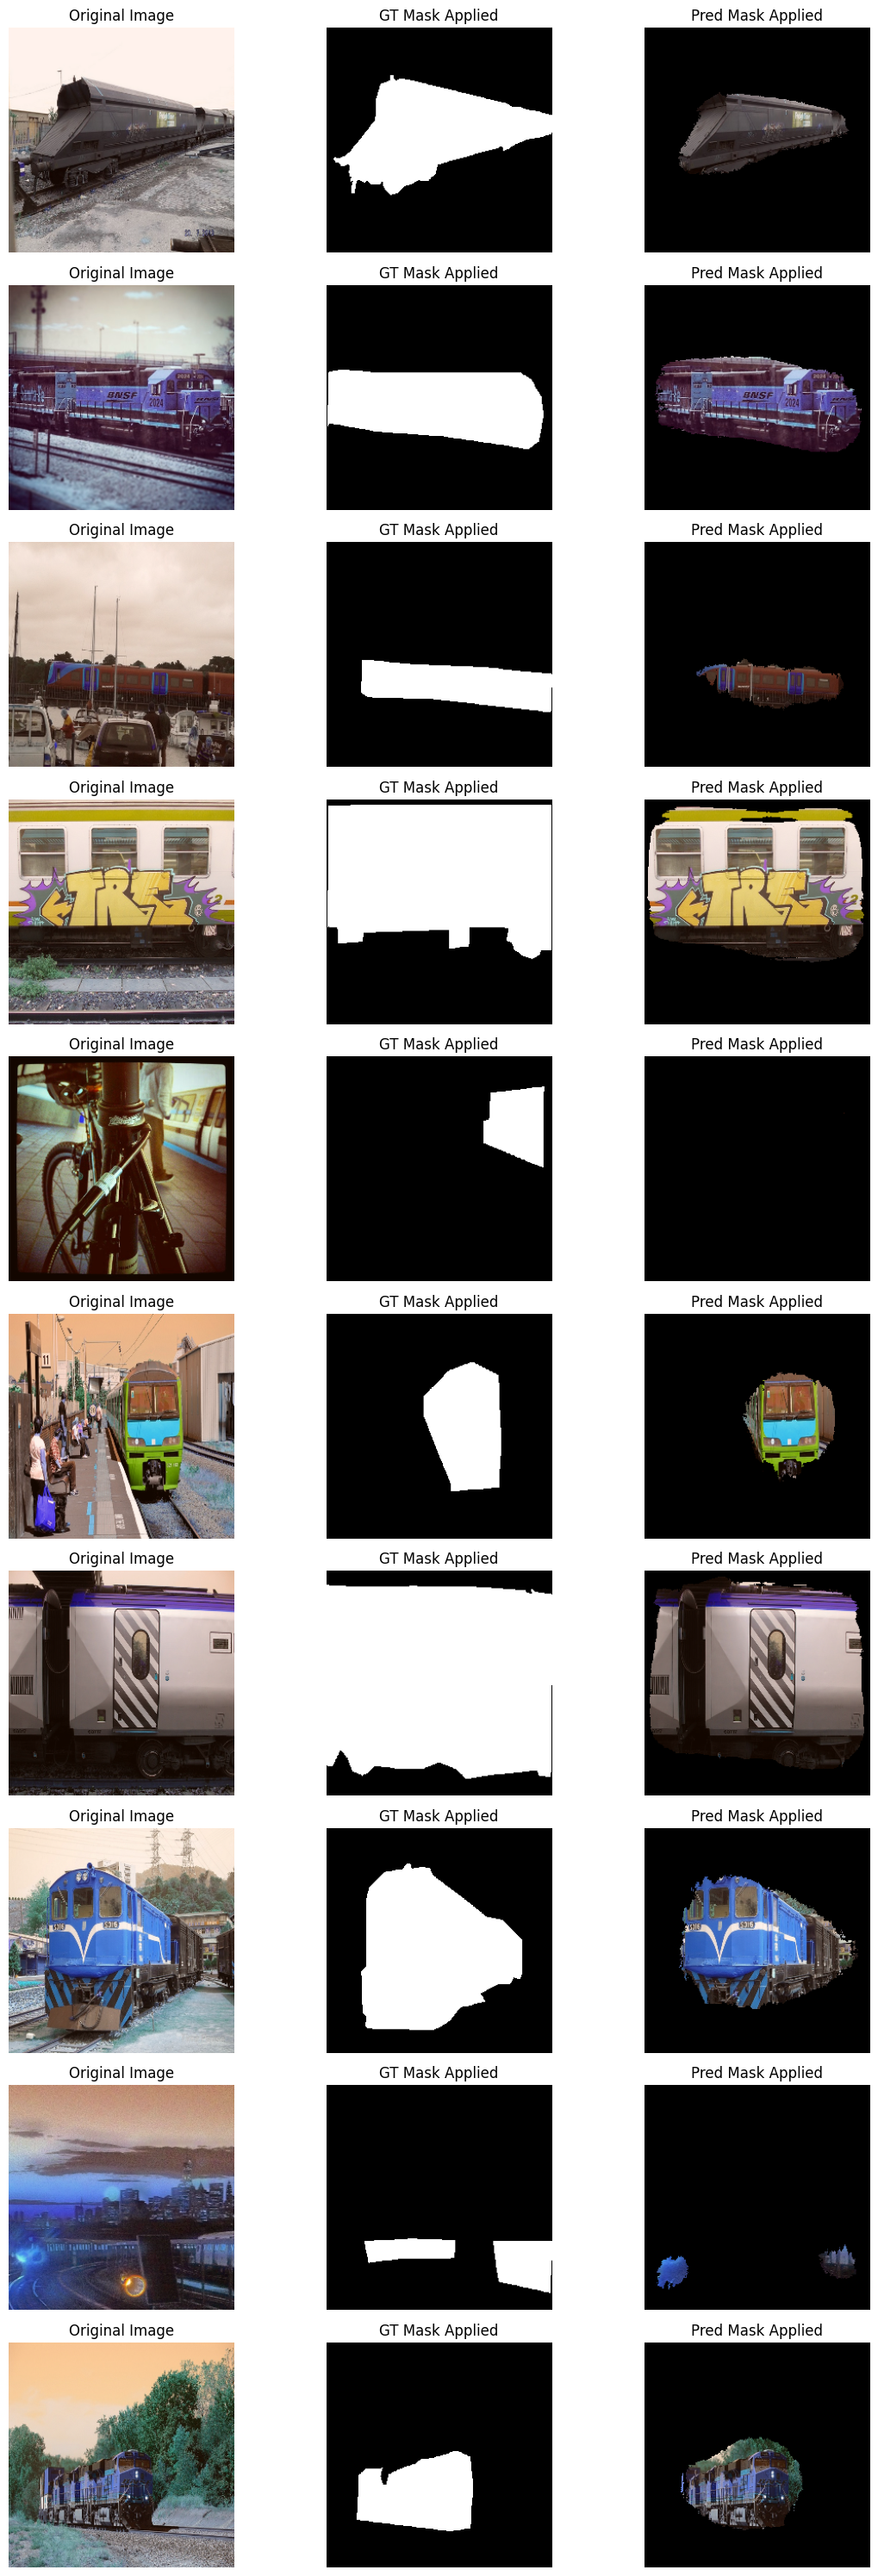

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Number of images to show (now 10 instead of 5)
num_show = min(10, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], num_show, replace=False)

# Get predictions
preds = model.predict(X_train[indices])
pred_bins = (preds > 0.5).astype(np.uint8)  # convert to binary masks

plt.figure(figsize=(12, num_show*3))

for i, idx in enumerate(indices):
    # Original image for display
    img_disp = X_train[idx].copy()
    img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min() + 1e-8)  # scale to 0..1

    # Ground truth mask (binary)
    gt_mask = y_train[idx].squeeze()

    # Pred masked image (applied like before)
    pred_mask = pred_bins[i].squeeze()
    if img_disp.shape[-1] == 1:  # grayscale → make RGB
        img_disp_rgb = np.repeat(img_disp, 3, axis=-1)
        pred_masked_img = np.zeros_like(img_disp_rgb)
        pred_masked_img[pred_mask == 1] = img_disp_rgb[pred_mask == 1]
    else:
        pred_masked_img = np.zeros_like(img_disp)
        pred_masked_img[pred_mask == 1] = img_disp[pred_mask == 1]

    # Plot original image
    plt.subplot(num_show, 3, i*3 + 1)
    plt.imshow(img_disp.squeeze(), cmap='gray' if img_disp.shape[-1]==1 else None)
    plt.title("Original Image")
    plt.axis('off')

    # Plot GT mask directly in black & white
    plt.subplot(num_show, 3, i*3 + 2)
    plt.imshow(gt_mask, cmap='gray')
    plt.title("GT Mask Applied")
    plt.axis('off')

    # Plot Pred-masked image
    plt.subplot(num_show, 3, i*3 + 3)
    plt.imshow(pred_masked_img)
    plt.title("Pred Mask Applied")
    plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Sample 1 - IoU: 0.8187, Pixel Accuracy: 0.9199
Sample 2 - IoU: 0.8011, Pixel Accuracy: 0.8723
Sample 3 - IoU: 0.6650, Pixel Accuracy: 0.9126
Sample 4 - IoU: 0.7615, Pixel Accuracy: 0.9333
Sample 5 - IoU: 0.7459, Pixel Accuracy: 0.9048


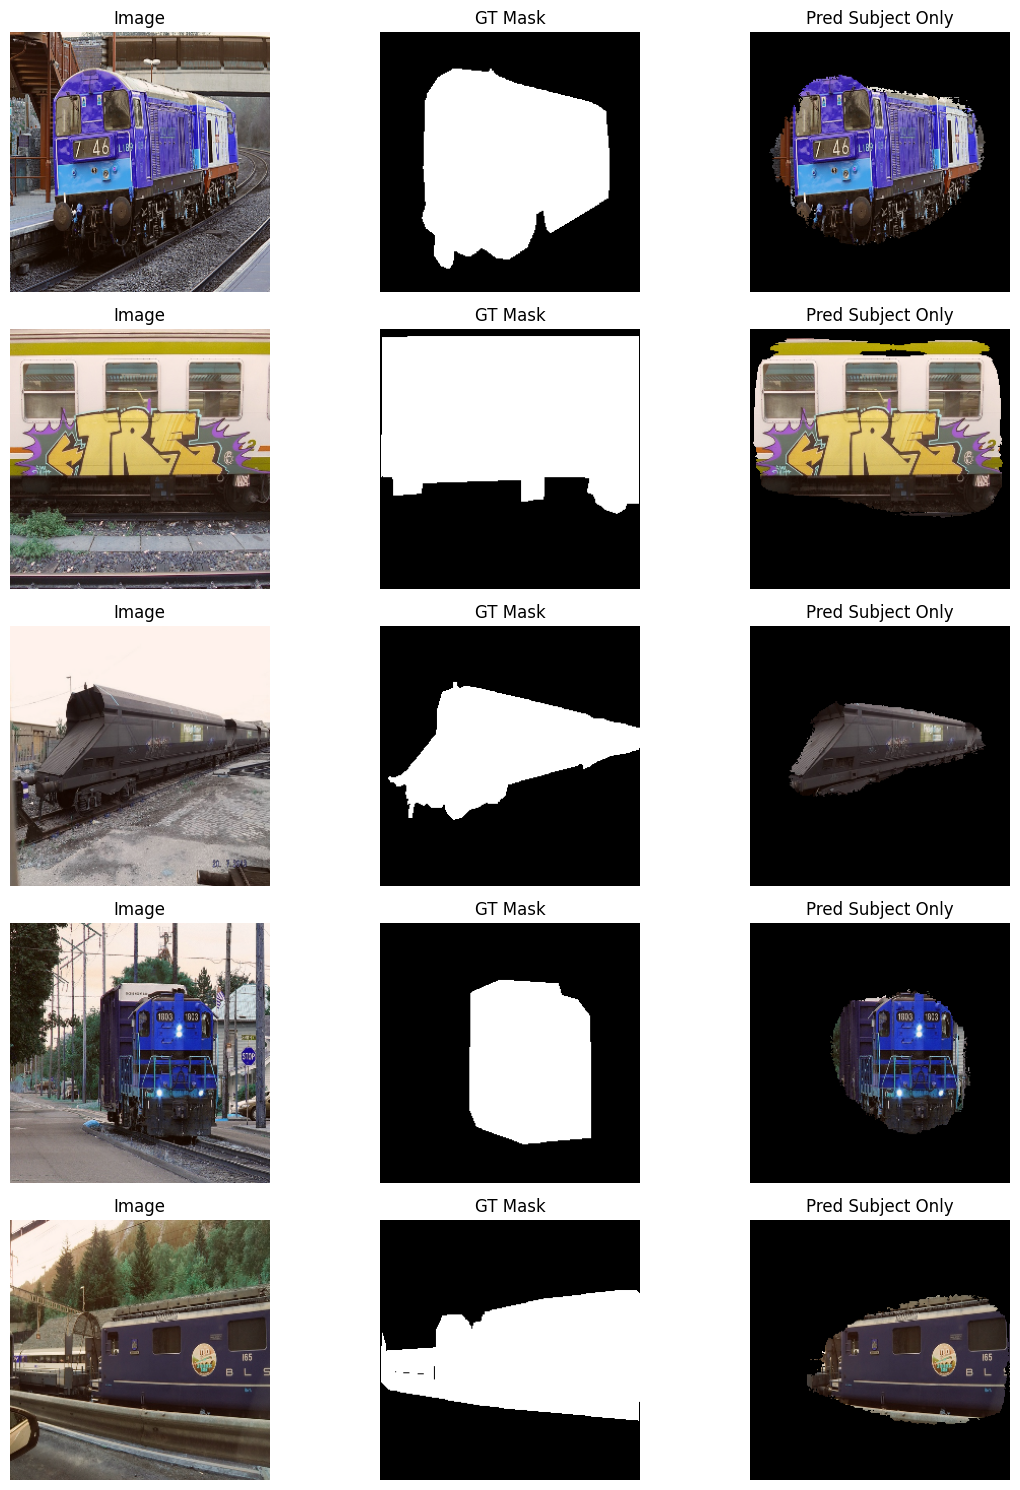


Average IoU: 0.7584
Average Pixel Accuracy: 0.9086


In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import jaccard_score

# Number of images to show
num_show = min(5, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], num_show, replace=False)

# Get predictions
preds = model.predict(X_train[indices])
pred_bins = (preds > 0.5).astype(np.uint8)  # binary masks

pixel_acc_list = []
iou_list = []

plt.figure(figsize=(12, num_show*3))

for i, idx in enumerate(indices):
    # Original image
    img_disp = X_train[idx].copy()
    img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min() + 1e-8)  # scale 0..1

    # Create masked image: main subject only
    mask = pred_bins[i].squeeze()
    masked_img = img_disp * mask[..., None]  # multiply mask with image

    # Plot original image
    plt.subplot(num_show, 3, i*3 + 1)
    plt.imshow(img_disp)
    plt.title("Image")
    plt.axis('off')

    # Plot ground truth mask
    plt.subplot(num_show, 3, i*3 + 2)
    plt.imshow(y_train[idx].squeeze(), cmap='gray')
    plt.title("GT Mask")
    plt.axis('off')

    # Plot predicted subject only
    plt.subplot(num_show, 3, i*3 + 3)
    plt.imshow(masked_img)
    plt.title("Pred Subject Only")
    plt.axis('off')

    # Compute IoU
    gt_flat = y_train[idx].flatten()
    pred_flat = mask.flatten()
    iou = jaccard_score(gt_flat, pred_flat, average='binary')
    iou_list.append(iou)

    # Compute Pixel Accuracy
    pixel_acc = np.sum(gt_flat == pred_flat) / len(gt_flat)
    pixel_acc_list.append(pixel_acc)

    print(f"Sample {i+1} - IoU: {iou:.4f}, Pixel Accuracy: {pixel_acc:.4f}")

plt.tight_layout()
plt.show()

# Average metrics over batch
avg_iou = np.mean(iou_list)
avg_pixel_acc = np.mean(pixel_acc_list)
print(f"\nAverage IoU: {avg_iou:.4f}")
print(f"Average Pixel Accuracy: {avg_pixel_acc:.4f}")


**Step 1: Load the Trained Model**

In [8]:
import tensorflow as tf

model_path = "/content/drive/MyDrive/VisionExtract/unet_resnet50_best.keras"
model = tf.keras.models.load_model(model_path, compile=False)


**Step 2: Prepare New Images**

In [9]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/VisionExtract/input_images/train_image.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (256, 256))
img_input = preprocess_input(img_resized.astype(np.float32))
img_input = np.expand_dims(img_input, axis=0)  # add batch dimension


**Step 3: Make Prediction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


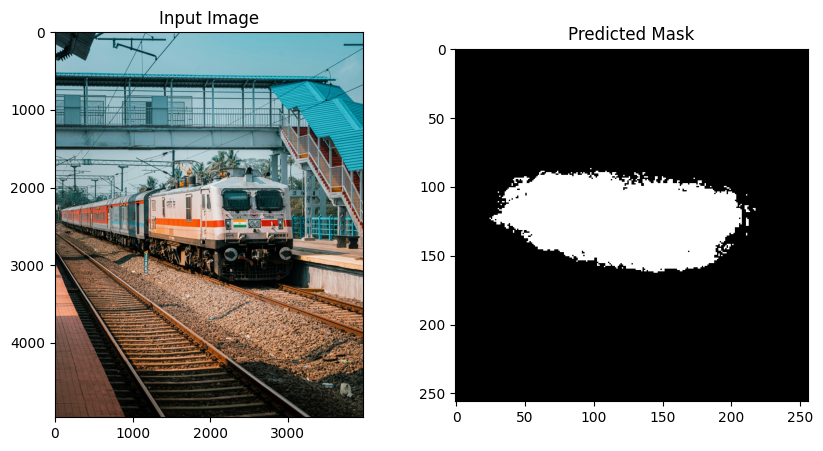

In [12]:
pred_mask = model.predict(img_input)[0]  # take the first (and only) prediction
pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)  # binary mask

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input Image")
plt.subplot(1,2,2)
plt.imshow(pred_mask_bin.squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


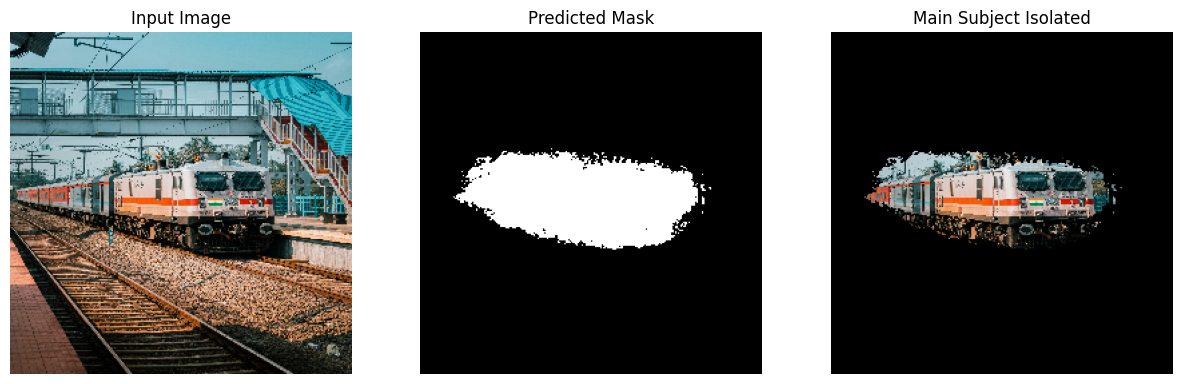

In [31]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# Load image
image_path = "/content/drive/MyDrive/VisionExtract/input_images/train_image.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (256, 256))
img_input = preprocess_input(img_resized.astype(np.float32))
img_input = np.expand_dims(img_input, axis=0)  # add batch dimension

# Predict mask
pred_mask = model.predict(img_input)[0]

# Resize prediction back to input size
pred_mask_resized = cv2.resize(pred_mask, (256, 256))

# Threshold to binary
pred_mask_bin = (pred_mask_resized > 0.5).astype(np.uint8)

# Convert binary mask to 3-channel 0–255
pred_mask_color = np.repeat(pred_mask_bin[:, :, np.newaxis], 3, axis=2) * 255

# Apply mask to original image
masked_img = cv2.bitwise_and(img_resized, pred_mask_color)

# Show results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask_bin.squeeze() * 255, cmap='gray')  # 0–255 black/white mask
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(masked_img)
plt.title("Main Subject Isolated")
plt.axis("off")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


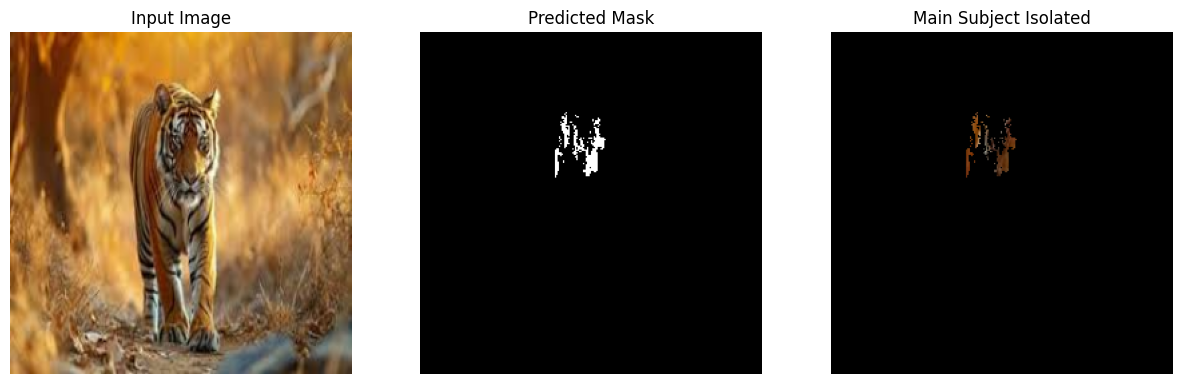

In [35]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# Load image
image_path = "/content/drive/MyDrive/VisionExtract/input_images/original.png"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (256, 256))
img_input = preprocess_input(img_resized.astype(np.float32))
img_input = np.expand_dims(img_input, axis=0)  # add batch dimension

# Predict mask
pred_mask = model.predict(img_input)[0]

# Resize prediction back to input size
pred_mask_resized = cv2.resize(pred_mask, (256, 256))

# Threshold to binary
pred_mask_bin = (pred_mask_resized > 0.5).astype(np.uint8)

# Convert binary mask to 3-channel 0–255
pred_mask_color = np.repeat(pred_mask_bin[:, :, np.newaxis], 3, axis=2) * 255

# Apply mask to original image
masked_img = cv2.bitwise_and(img_resized, pred_mask_color)

# Show results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask_bin.squeeze() * 255, cmap='gray')  # 0–255 black/white mask
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(masked_img)
plt.title("Main Subject Isolated")
plt.axis("off")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step


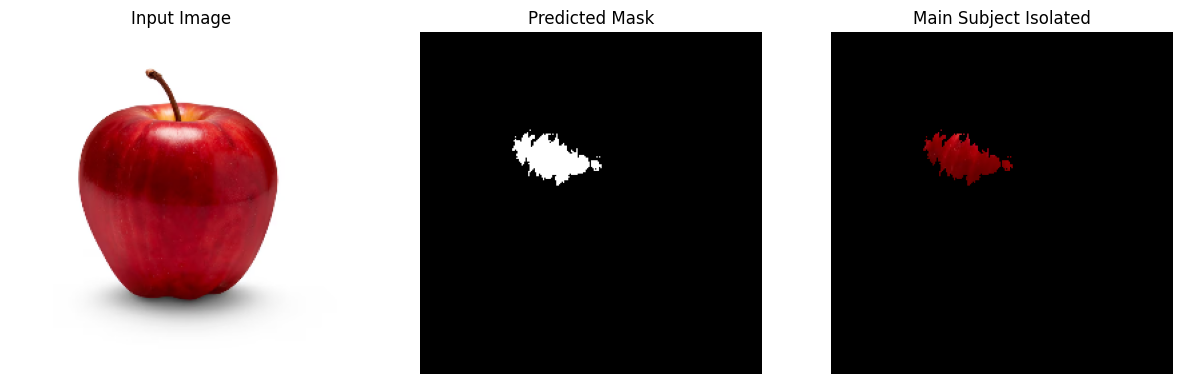

In [36]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# Load image
image_path = "/content/drive/MyDrive/VisionExtract/input_images/apple_imag.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (256, 256))
img_input = preprocess_input(img_resized.astype(np.float32))
img_input = np.expand_dims(img_input, axis=0)  # add batch dimension

# Predict mask
pred_mask = model.predict(img_input)[0]

# Resize prediction back to input size
pred_mask_resized = cv2.resize(pred_mask, (256, 256))

# Threshold to binary
pred_mask_bin = (pred_mask_resized > 0.5).astype(np.uint8)

# Convert binary mask to 3-channel 0–255
pred_mask_color = np.repeat(pred_mask_bin[:, :, np.newaxis], 3, axis=2) * 255

# Apply mask to original image
masked_img = cv2.bitwise_and(img_resized, pred_mask_color)

# Show results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask_bin.squeeze() * 255, cmap='gray')  # 0–255 black/white mask
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(masked_img)
plt.title("Main Subject Isolated")
plt.axis("off")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


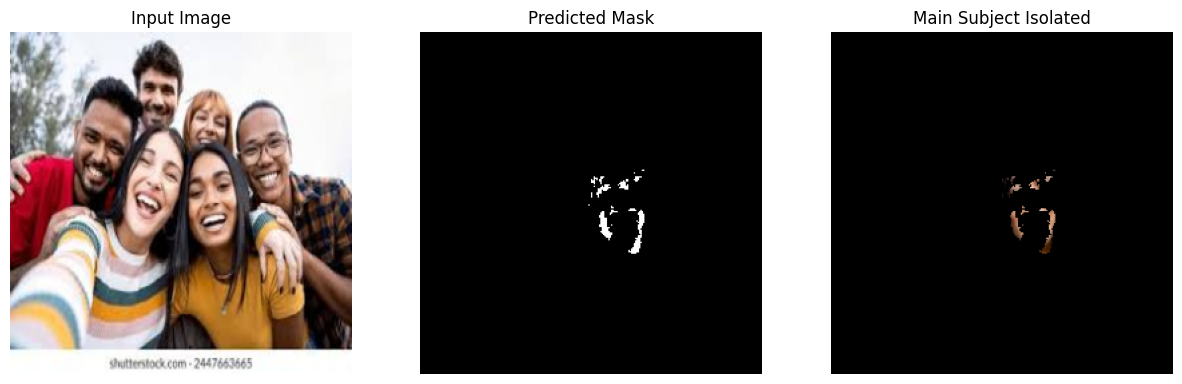

In [34]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

# Load image
image_path = "/content/drive/MyDrive/VisionExtract/input_images/humans_image.jpeg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (256, 256))
img_input = preprocess_input(img_resized.astype(np.float32))
img_input = np.expand_dims(img_input, axis=0)  # add batch dimension

# Predict mask
pred_mask = model.predict(img_input)[0]   # shape could be smaller (e.g. 32x32)

# Resize mask back to input size (256x256)
pred_mask_resized = cv2.resize(pred_mask, (256, 256))

# Threshold to binary (try 0.3 if 0.5 is too strict)
pred_mask_bin = (pred_mask_resized > 0.5).astype(np.uint8)

# Convert binary mask to 3-channel 0–255 format
pred_mask_color = np.repeat(pred_mask_bin[:, :, np.newaxis], 3, axis=2) * 255

# Apply mask to original image (clear subject isolated)
masked_img = cv2.bitwise_and(img_resized, pred_mask_color)

# Show results
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img_resized)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask_bin.squeeze() * 255, cmap='gray')  # show mask as black/white
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(masked_img)
plt.title("Main Subject Isolated")
plt.axis("off")

plt.show()
